In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns

In [2]:
data_1 = np.load("/app/outputs/mc_calibration/kl_and_target.npz")
X = np.concatenate([data_1["kl_1"][None, :], data_1["kl_2"][None, :]], axis=0)
y = data_1["true_pred_label"].astype("bool")
data_100 = np.load("/app/outputs/mc_calibration/kl_and_target_100.npz")
data_30 = np.load("/app/outputs/mc_calibration/kl_and_target_30.npz")
data_300 = np.load("/app/outputs/mc_calibration/kl_and_target_300.npz")
data_3000 = np.load("/app/outputs/mc_calibration/kl_and_target_3000.npz")

In [3]:
y.shape[0], y.sum(), y.sum() / y.shape[0]

(19593, 18658, 0.9522788751084571)

### Train classifier

In [8]:
def train_perceptron(
    data, model, epochs=100, lr=0.001, weight_decay=0.0001, weight=None
):
    X = torch.tensor(
        np.concatenate([data["kl_1"][None, :], data["kl_2"][None, :]], axis=0).T,
        dtype=torch.float32,
    )
    X_norm = (X - torch.mean(X, dim=0)) / torch.std(X, dim=0)
    y = torch.tensor(data["true_pred_label"].astype("bool"), dtype=torch.float32)
    weights = torch.zeros_like(y)
    if weight is None:
        true_pred_ratio = y.sum() / y.shape[0]
        print(true_pred_ratio.item())
        weight = true_pred_ratio.item()
    weight = torch.tensor(weight)
    weights[y == 1.0] = 1 - weight
    weights[y == 0.0] = weight

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCELoss(weight=weight)
    for iter in range(epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_norm)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        model.eval()
        pred_eval = model(X_norm)
        accuracy = np.mean((pred_eval.detach().numpy() > 0.5) == y.numpy())
        print(f"Iteration {iter}, Loss: {loss.item()}, accuracy: {accuracy.item()}")

In [9]:
# train small perceptron
hidden_size = 8
small_perceptron = nn.Sequential(
    nn.Linear(2, hidden_size),
    nn.BatchNorm1d(hidden_size, affine=True),
    nn.Sigmoid(),
    nn.Linear(hidden_size, hidden_size),
    nn.BatchNorm1d(hidden_size, affine=True),
    nn.Sigmoid(),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid(),
    nn.Flatten(start_dim=0),
)
train_perceptron(data_30, small_perceptron, lr=0.001, epochs=1000)

0.9522788524627686
Iteration 0, Loss: 0.6202911734580994, accuracy: 0.9522788751084571
Iteration 1, Loss: 0.6177896857261658, accuracy: 0.9522788751084571
Iteration 2, Loss: 0.6153263449668884, accuracy: 0.9522788751084571
Iteration 3, Loss: 0.6129043698310852, accuracy: 0.9522788751084571
Iteration 4, Loss: 0.6105246543884277, accuracy: 0.9522788751084571
Iteration 5, Loss: 0.6081864833831787, accuracy: 0.9522788751084571
Iteration 6, Loss: 0.6058865785598755, accuracy: 0.9522788751084571
Iteration 7, Loss: 0.6036205887794495, accuracy: 0.9522788751084571
Iteration 8, Loss: 0.6013834476470947, accuracy: 0.9522788751084571
Iteration 9, Loss: 0.599170446395874, accuracy: 0.9522788751084571
Iteration 10, Loss: 0.5969780087471008, accuracy: 0.9522788751084571
Iteration 11, Loss: 0.5948032736778259, accuracy: 0.9522788751084571
Iteration 12, Loss: 0.5926445722579956, accuracy: 0.9522788751084571
Iteration 13, Loss: 0.590501606464386, accuracy: 0.9522788751084571
Iteration 14, Loss: 0.58837

In [10]:
# # train big perceptron
# hidden_size = 32
# perceptron = nn.Sequential(
#     nn.Linear(2, hidden_size),
#     nn.BatchNorm1d(hidden_size, affine=True),
#     nn.Sigmoid(),
#     nn.Linear(hidden_size, hidden_size),
#     nn.BatchNorm1d(hidden_size, affine=True),
#     nn.Sigmoid(),
#     nn.Linear(hidden_size, hidden_size),
#     nn.Sigmoid(),
#     nn.Linear(hidden_size, hidden_size),
#     nn.BatchNorm1d(hidden_size, affine=True),
#     nn.Linear(hidden_size, 1),
#     nn.Sigmoid(),
#     nn.Flatten(start_dim=0),
# )
# train_perceptron(data_30, perceptron, epochs=100, lr=0.01, weight_decay=0.001)

### Predict

<AxesSubplot:xlabel='kl_1', ylabel='kl_2'>

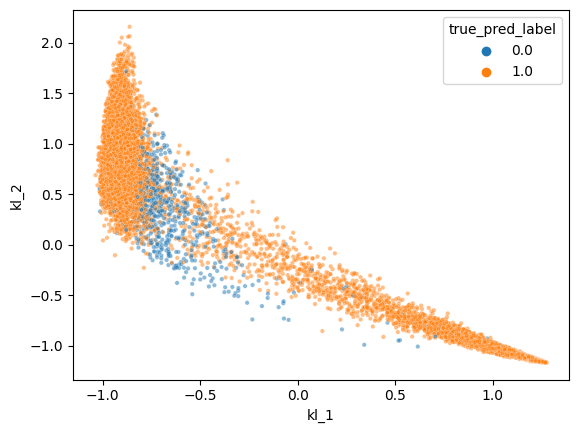

In [11]:
data = data_30
X = torch.tensor(
    np.concatenate([data["kl_1"][None, :], data["kl_2"][None, :]], axis=0).T,
    dtype=torch.float32,
)
X_norm = (X - torch.mean(X, dim=0)) / torch.std(X, dim=0)
y = torch.tensor(data["true_pred_label"].astype("bool"), dtype=torch.float32)

sns.scatterplot(
    data={"kl_1": X_norm[:, 0], "kl_2": X_norm[:, 1], "true_pred_label": y},
    x="kl_1",
    y="kl_2",
    hue="true_pred_label",
    s=10,
    alpha=0.5,
)

In [ ]:
from matplotlib import cm, ticker


def draw_data_and_pred(data, model, size=500):
    X = torch.tensor(
        np.concatenate([data["kl_1"][None, :], data["kl_2"][None, :]], axis=0).T,
        dtype=torch.float32,
    )
    X_norm = (X - torch.mean(X, dim=0)) / torch.std(X, dim=0)
    y = torch.tensor(data["true_pred_label"].astype("bool"), dtype=torch.float32)

    kl_1 = torch.linspace(X_norm[:, 0].min(), X_norm[:, 0].max(), size)
    kl_2 = torch.linspace(X_norm[:, 1].min(), X_norm[:, 1].max(), size)
    grid_x, grid_y = np.meshgrid(kl_1.numpy(), kl_2.numpy(), indexing="ij")
    product = torch.cartesian_prod(kl_1, kl_2)

    model.eval()
    predict_prob = model(product)
    z = np.reshape(predict_prob.detach().numpy(), (size, size)).T
    z_min, z_max = z.min(), z.max()

    fig, ax = plt.subplots()
    cs = ax.contourf(grid_x, grid_y, z, cmap=cm.PuBu_r, vmin=z_min, vmax=z_max)
    ax.axis([grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()])
    cbar = fig.colorbar(cs)
    sns.scatterplot(
        data={"kl_1": X_norm[:, 0], "kl_2": X_norm[:, 1], "true_pred_label": y},
        x="kl_1",
        y="kl_2",
        hue="true_pred_label",
        s=10,
        alpha=0.5,
    )
    plt.show()

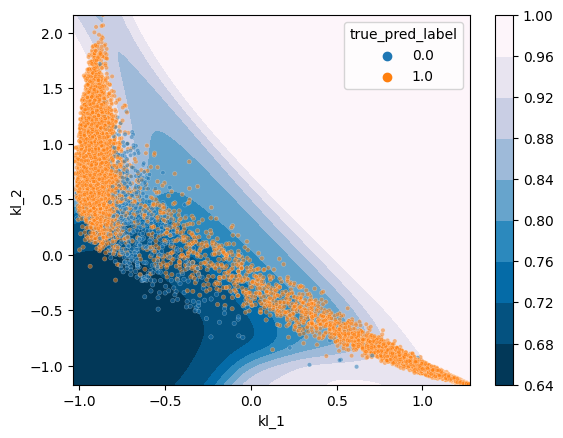

In [13]:
draw_data_and_pred(data_30, small_perceptron)

In [14]:
# draw_data_and_pred(data_30, perceptron)

In [15]:
from evaluation.visualize import plot_rejection_scores


def get_rejection_accuracy(model_names, unc_list, labels, fractions):
    metric_scores = []
    fractions_linspace = np.linspace(fractions[0], fractions[1], fractions[2])
    for unc in unc_list:
        accuracies = []
        unc_indexes = np.argsort(unc)
        for fraction in fractions_linspace:
            good_idx = unc_indexes[: int((1 - fraction) * unc.shape[0])]
            accuracies.append(np.mean(labels[good_idx]))

        metric_scores.append((fractions_linspace, accuracies))

    metric_pretty_name = "Accuracy"
    fig, rejection_metric_values = plot_rejection_scores(
        scores=metric_scores,
        names=model_names,
        y_label=f"{metric_pretty_name}",
    )
    return fig

In [16]:
a = np.load("/app/outputs/mc_calibration/scf.npz")
scf_conf = a["kappa"]

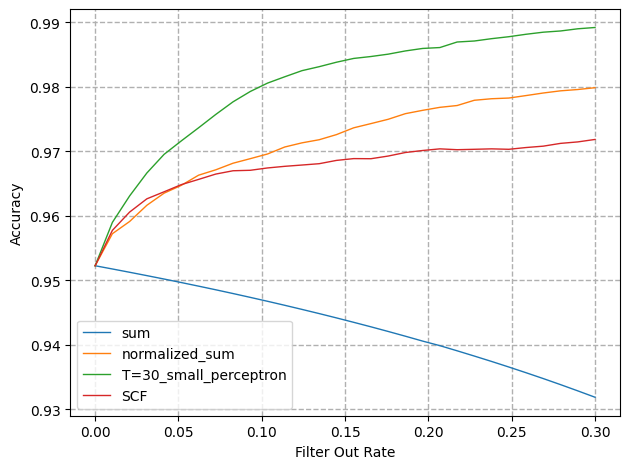

In [17]:
fractions = [0, 0.3, 30]
fractions_linspace = np.linspace(fractions[0], fractions[1], fractions[2])


small_perceptron.eval()
# perceptron.eval()

predict_small_perceptron = small_perceptron(X_norm)
# predict_perceptron = perceptron(X_norm)

model_names = [
    "sum",
    "normalized_sum",
    "T=30_small_perceptron",
    # "T=30_perceptron",
    "SCF",
]
sum_unc = torch.sum(X, dim=1)
normalized_sum_confidence = torch.sum(X_norm, dim=1)
unc_list = [
    -sum_unc.numpy(),
    -normalized_sum_confidence.numpy(),
    -predict_small_perceptron.detach().numpy(),
    # -predict_perceptron.detach().numpy(),
    -scf_conf,
]
fig = get_rejection_accuracy(model_names, unc_list, y.numpy(), fractions)
fig.show()

In [18]:
# sns.relplot(
#     data=data,
#     x="kl_1",
#     y="kl_2",
#     col="true_pred_label",
#     hue="true_pred_label",
#     kind="scatter",
# )
# sns.relplot(
#     data=data_30,
#     x="kl_1",
#     y="kl_2",
#     col="true_pred_label",
#     hue="true_pred_label",
#     kind="scatter",
# )
# sns.relplot(
#     data=data_100,
#     x="kl_1",
#     y="kl_2",
#     col="true_pred_label",
#     hue="true_pred_label",
#     kind="scatter",
# )
# sns.relplot(
#     data=data_300,
#     x="kl_1",
#     y="kl_2",
#     col="true_pred_label",
#     hue="true_pred_label",
#     kind="scatter",
# )
# sns.scatterplot(
#     data=data_30, x="kl_1", y="kl_2", hue="true_pred_label", s=10, alpha=0.5
# )

### Validation ms1m set

In [19]:
data_30_ms1m = np.load("/app/outputs/mc_calibration_ms1m/kl_and_target_30_M=0.npz")
scf = np.load("/app/outputs/mc_calibration_ms1m/scf.npz")
scf_conf_ms1m = scf["kappa"]

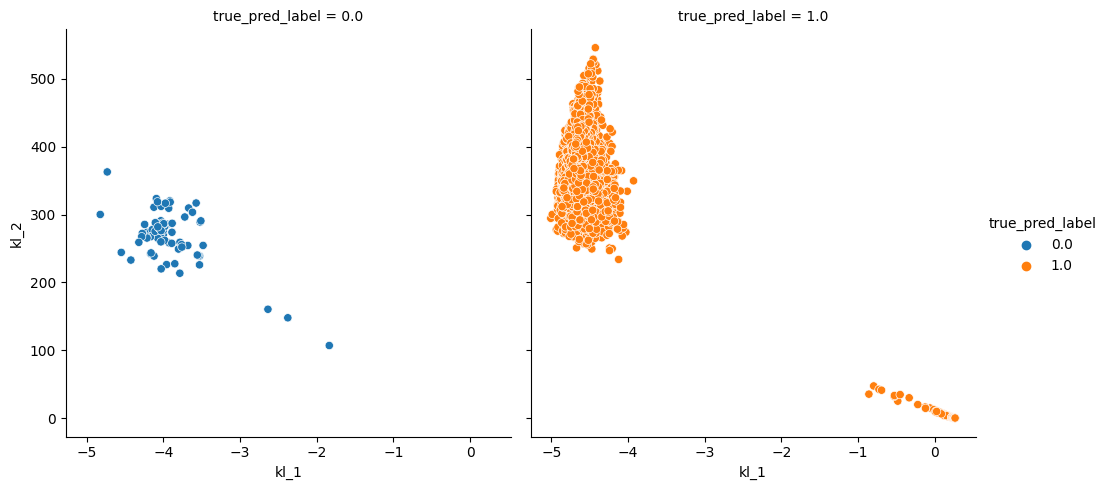

In [20]:
sns.relplot(
    data=data_30_ms1m,
    x="kl_1",
    y="kl_2",
    col="true_pred_label",
    hue="true_pred_label",
    kind="scatter",
)

In [21]:
# train small perceptron ms1m
hidden_size = 32
perceptron_ms1m = nn.Sequential(
    nn.Linear(2, hidden_size),
    nn.BatchNorm1d(hidden_size, affine=True),
    nn.Sigmoid(),
    nn.Linear(hidden_size, hidden_size),
    nn.BatchNorm1d(hidden_size, affine=True),
    nn.Sigmoid(),
    nn.Linear(hidden_size, hidden_size),
    nn.Sigmoid(),
    nn.Linear(hidden_size, hidden_size),
    nn.BatchNorm1d(hidden_size, affine=True),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid(),
    nn.Flatten(start_dim=0),
)
train_perceptron(data_30_ms1m, perceptron_ms1m, lr=0.001, epochs=1500, weight=0.95)

Iteration 0, Loss: 0.7517112493515015, accuracy: 0.9946898895497026
Iteration 1, Loss: 0.6523726582527161, accuracy: 0.9946898895497026
Iteration 2, Loss: 0.6059156060218811, accuracy: 0.9946898895497026
Iteration 3, Loss: 0.5998250842094421, accuracy: 0.9946898895497026
Iteration 4, Loss: 0.6026983261108398, accuracy: 0.9946898895497026
Iteration 5, Loss: 0.6026246547698975, accuracy: 0.9946898895497026
Iteration 6, Loss: 0.599585771560669, accuracy: 0.9946898895497026
Iteration 7, Loss: 0.5946038961410522, accuracy: 0.9946898895497026
Iteration 8, Loss: 0.5898268818855286, accuracy: 0.9946898895497026
Iteration 9, Loss: 0.5882037281990051, accuracy: 0.9946898895497026
Iteration 10, Loss: 0.5878831744194031, accuracy: 0.9946898895497026
Iteration 11, Loss: 0.5867822766304016, accuracy: 0.9946898895497026
Iteration 12, Loss: 0.584760308265686, accuracy: 0.9946898895497026
Iteration 13, Loss: 0.582192063331604, accuracy: 0.9946898895497026
Iteration 14, Loss: 0.5795210003852844, accurac

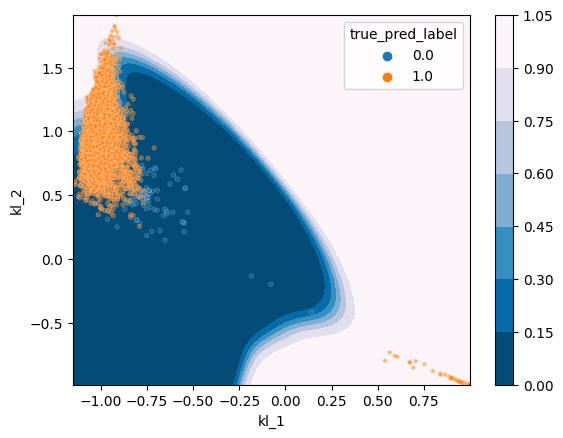

In [22]:
draw_data_and_pred(data_30_ms1m, perceptron_ms1m)

<AxesSubplot:xlabel='kl_1', ylabel='kl_2'>

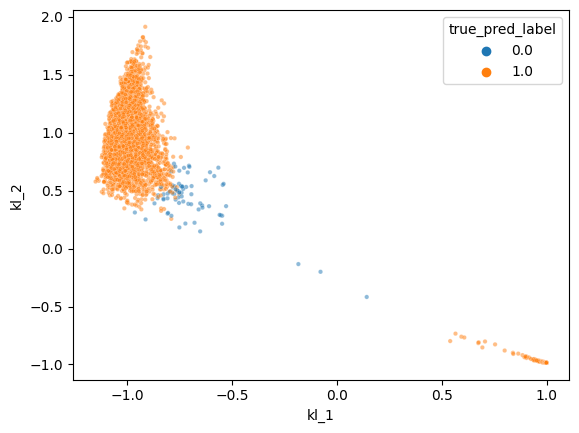

In [23]:
data = data_30_ms1m
X_ms1m = torch.tensor(
    np.concatenate([data["kl_1"][None, :], data["kl_2"][None, :]], axis=0).T,
    dtype=torch.float32,
)
X_norm = (X_ms1m - torch.mean(X_ms1m, dim=0)) / torch.std(X_ms1m, dim=0)
y = torch.tensor(data["true_pred_label"].astype("bool"), dtype=torch.float32)

sns.scatterplot(
    data={"kl_1": X_norm[:, 0], "kl_2": X_norm[:, 1], "true_pred_label": y},
    x="kl_1",
    y="kl_2",
    hue="true_pred_label",
    s=10,
    alpha=0.5,
)

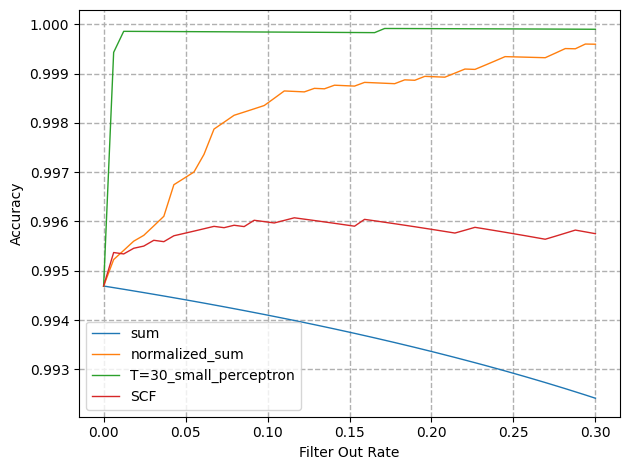

In [30]:
fractions = [0, 0.3, 50]
fractions_linspace = np.linspace(fractions[0], fractions[1], fractions[2])


perceptron_ms1m.eval()
# perceptron.eval()

predict_small_perceptron = perceptron_ms1m(X_norm)
# predict_perceptron = perceptron(X_norm)

model_names = [
    "sum",
    "normalized_sum",
    "T=30_small_perceptron",
    # "T=30_perceptron",
    "SCF",
]
sum_unc = torch.sum(X_ms1m, dim=1)
normalized_sum_confidence = torch.sum(X_norm, dim=1)
unc_list = [
    -sum_unc.numpy(),
    -normalized_sum_confidence.numpy(),
    -predict_small_perceptron.detach().numpy(),
    # -predict_perceptron.detach().numpy(),
    -scf_conf_ms1m,
]
fig = get_rejection_accuracy(model_names, unc_list, y.numpy(), fractions)
fig.show()

### Predict on test

In [31]:
data = data_30
X = torch.tensor(
    np.concatenate([data["kl_1"][None, :], data["kl_2"][None, :]], axis=0).T,
    dtype=torch.float32,
)
X_norm = (X - torch.mean(X, dim=0)) / torch.std(X, dim=0)
X_norm_ms1m = (X - torch.mean(X_ms1m, dim=0)) / torch.std(X_ms1m, dim=0)
y = torch.tensor(data["true_pred_label"].astype("bool"), dtype=torch.float32)

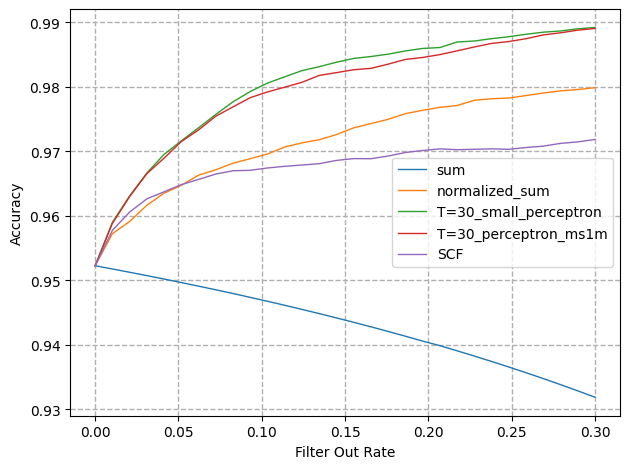

In [32]:
fractions = [0, 0.3, 30]
fractions_linspace = np.linspace(fractions[0], fractions[1], fractions[2])


small_perceptron.eval()
perceptron_ms1m.eval()
# perceptron.eval()

predict_small_perceptron = small_perceptron(X_norm)
predictions_perceptron_ms1m = perceptron_ms1m(X_norm_ms1m)
# predict_perceptron = perceptron(X_norm)

model_names = [
    "sum",
    "normalized_sum",
    "T=30_small_perceptron",
    "T=30_perceptron_ms1m",
    "SCF",
]
sum_unc = torch.sum(X, dim=1)
normalized_sum_confidence = torch.sum(X_norm, dim=1)
unc_list = [
    -sum_unc.numpy(),
    -normalized_sum_confidence.numpy(),
    -predict_small_perceptron.detach().numpy(),
    -predictions_perceptron_ms1m.detach().numpy(),
    -scf_conf,
]
fig = get_rejection_accuracy(model_names, unc_list, y.numpy(), fractions)
fig.show()